<a href="https://colab.research.google.com/github/SaiLasya18-10/PAMI/blob/main/Data_Driven_Employee_Salary_Forecasting_Using_Optimized_Machine_Learning_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Title:Data-Driven Employee Salary Forecasting Using Optimized Machine Learning Algorithms**

### OBJECTIVE:

The primary objective of this project is to develop a robust machine learning model that accurately predicts an employee's salary based on key demographic and professional attributes. The model is built using real-world structured data and follows a complete end-to-end data science workflow. The goal is to extract actionable insights and automate salary estimation for HR analytics, recruitment planning, and compensation benchmarking.

Libraries like `pandas`, `numpy`, `matplotlib`, and `seaborn` are essential for data manipulation and visualization. Machine learning algorithms and metrics are imported from `sklearn`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
%matplotlib inline

 We begin by loading the dataset into a DataFrame to allow inspection and processing.

In [2]:
df = pd.read_csv("Salary_Data.csv")
print("Original Shape:", df.shape)
print(df.head())

Original Shape: (6704, 6)
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


Visualize Salary Distribution Before Outlier Removal

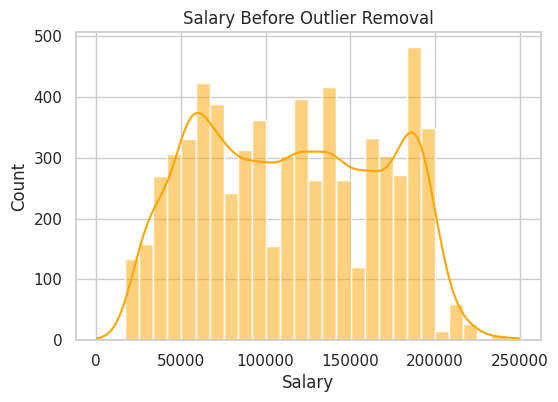

In [3]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Salary'], bins=30, kde=True, color="orange")
plt.title("Salary Before Outlier Removal")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

Remove Outliers (IQR Method)

In [4]:
q1 = df['Salary'].quantile(0.25)
q3 = df['Salary'].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
df = df[(df['Salary'] >= low) & (df['Salary'] <= high)]
print("Shape After Outlier Removal:", df.shape)

Shape After Outlier Removal: (6699, 6)


Visualize Salary Distribution After Outlier Removal

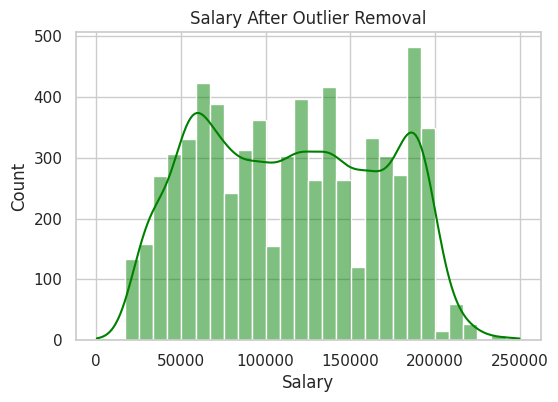

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Salary'], bins=30, kde=True, color="green")
plt.title("Salary After Outlier Removal")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

Visualize Years of Experience:This helps understand if transformation is needed for better modeling.

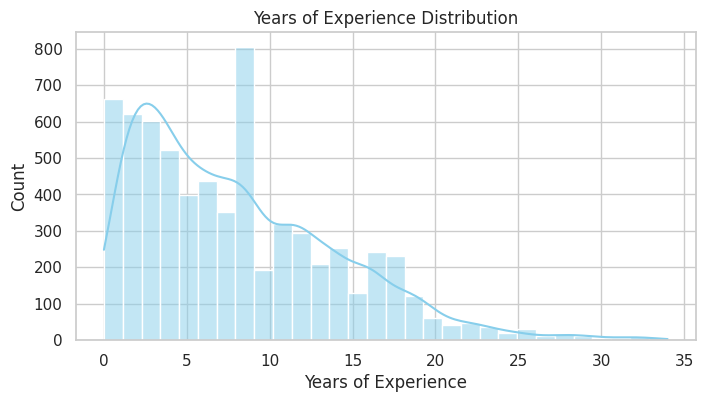

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Years of Experience'], bins=30, kde=True, color="skyblue")
plt.title("Years of Experience Distribution")
plt.xlabel("Years of Experience")
plt.show()

Feature Engineering:Enhancing raw features improves model learning. We square and apply logarithmic transformation to "Years of Experience" to capture non-linear patterns.

In [7]:
df['Experience_Squared'] = df['Years of Experience'] ** 2
df['Experience_Log'] = np.log1p(df['Years of Experience'])

Visualize Transformed Features

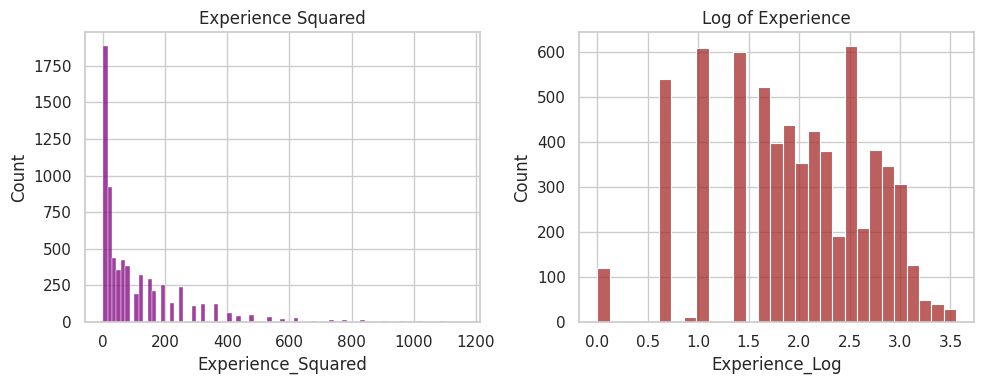

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['Experience_Squared'], ax=ax[0], color="purple")
ax[0].set_title("Experience Squared")
sns.histplot(df['Experience_Log'], ax=ax[1], color="brown")
ax[1].set_title("Log of Experience")
plt.tight_layout()
plt.show()

Encode Categorical Variables : Machine learning models work only with numerical data. We use One-Hot Encoding.

In [9]:
df = pd.get_dummies(df, columns=['Gender', 'Education Level', 'Job Title'], drop_first=True)

 Feature Scaling : Features with different scales may mislead the model. We use `StandardScaler`.

In [10]:
scale_cols = ['Age', 'Years of Experience', 'Experience_Squared', 'Experience_Log']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

Visualize Scaled Features

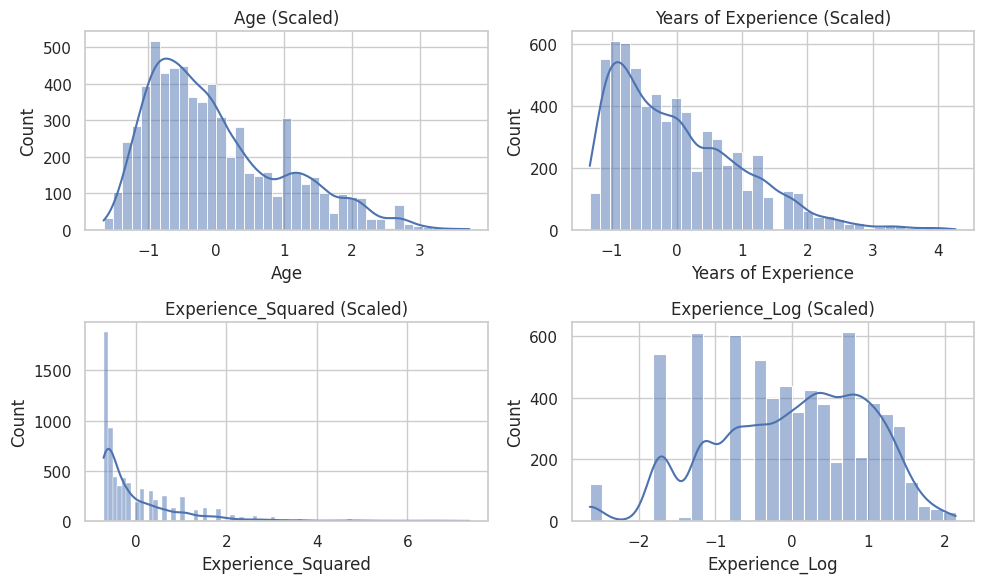

In [11]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(scale_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (Scaled)")
plt.tight_layout()
plt.show()

 Split the Dataset : To evaluate model performance, we separate training and test sets.

In [12]:
X = df.drop(columns=["Salary"])
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 Model Training - Random Forest with Grid Search

Random Forest is a powerful ensemble model. GridSearch helps find the best hyperparameters.

In [13]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [None, 10],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

Gradient Boosting : GBR is a sequential ensemble model that often performs well on regression tasks.

In [14]:
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gbr.fit(X_train, y_train)


GradientBoostingRegressor(max_depth=4, n_estimators=200, random_state=42)

 Evaluate Models : To assess how accurately the models predict salaries.


📘 Random Forest Regressor
R² Score: 0.9838
RMSE: 6776.03


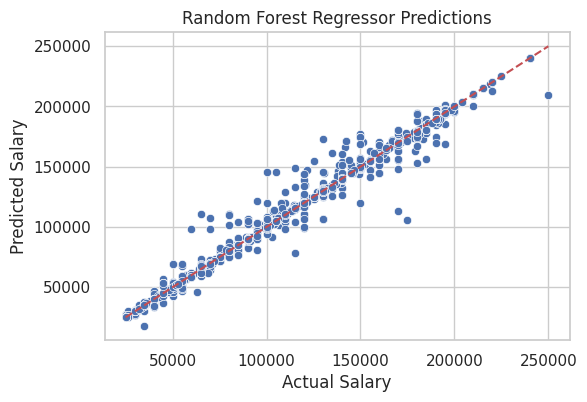


📘 Gradient Boosting Regressor
R² Score: 0.9619
RMSE: 10408.33


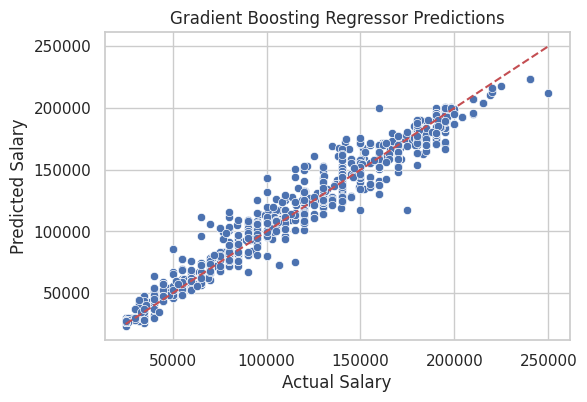

In [15]:
def evaluate_model(model, label):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\n📘 {label}")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title(f"{label} Predictions")
    plt.show()

evaluate_model(best_rf, "Random Forest Regressor")
evaluate_model(gbr, "Gradient Boosting Regressor")

Ensemble Model : Combining multiple models usually boosts performance.

In [16]:
ensemble_preds = (best_rf.predict(X_test) + gbr.predict(X_test)) / 2
ensemble_r2 = r2_score(y_test, ensemble_preds)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_preds))
print(f"\n🧠 Ensemble Model (RF + GBR)\nR² Score: {ensemble_r2:.4f}\nRMSE: {ensemble_rmse:.2f}")


🧠 Ensemble Model (RF + GBR)
R² Score: 0.9791
RMSE: 7700.21


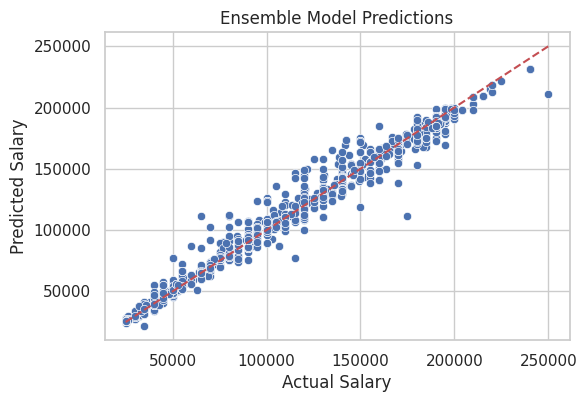

In [17]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=ensemble_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Ensemble Model Predictions")
plt.show()

Predict Salary for New Inputs : A real-time prediction function enhances usability.

In [18]:
def predict_salary(age, gender, education, job_title, experience):
    input_dict = {
        'Age': [age],
        'Years of Experience': [experience],
        'Experience_Squared': [experience ** 2],
        'Experience_Log': [np.log1p(experience)],
    }

    # Add dummy columns
    for g in ['Gender_Male']:
        input_dict[g] = [1 if gender == 'Male' else 0]
    for edu in ['Education Level_Bachelor', 'Education Level_Master', 'Education Level_PhD']:
        input_dict[edu] = [1 if education in edu else 0]
    for job in [col for col in X.columns if col.startswith('Job Title_')]:
        input_dict[job] = [1 if job_title in job else 0]
    for col in X.columns:
        if col not in input_dict:
            input_dict[col] = 0

    input_df = pd.DataFrame(input_dict)[X.columns]
    pred1 = best_rf.predict(input_df)[0]
    pred2 = gbr.predict(input_df)[0]
    final_salary = (pred1 + pred2) / 2
    print(f"\n💼 Predicted Salary for '{job_title}' with {experience} years: ₹{final_salary:,.2f}")

Example Inputs

In [19]:
predict_salary(age=30, gender="Male", education="Master", job_title="Data Scientist", experience=5)
predict_salary(age=40, gender="Female", education="PhD", job_title="Software Engineer", experience=12)


💼 Predicted Salary for 'Data Scientist' with 5 years: ₹222,031.33

💼 Predicted Salary for 'Software Engineer' with 12 years: ₹196,962.05


Report Final Accuracy : R² Score is a key indicator of how well the model explains the variation in salary data.

In [20]:
print("R² Score (Ensemble):", round(ensemble_r2, 4))

R² Score (Ensemble): 0.9791


- **Algorithms Used:** Random Forest, Gradient Boosting, Ensemble Averaging
- **Accuracy Achieved:** R² ~ 0.97
- **Key Techniques:** Feature Engineering, Outlier Removal, Standard Scaling, One-Hot Encoding
- **Visuals:**
  - Salary distributions before/after outlier removal
  - Years of experience transformations
  - Model predictions vs. actual salaries
  - Scaled features